# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

# mostrar las primeras 5 filas de plans
plans.head()

# mostrar las primeras 5 filas de users
users.head()

# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [2]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [3]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [4]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [5]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [6]:
# cantidad de nulos para users
print("Cantidad de valores nulos (users):")
print(users.isna().sum())

print("\nProporción de valores nulos (users):")
print(users.isna().mean())


Cantidad de valores nulos (users):
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos (users):
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [7]:
# cantidad de nulos para usage
print("\nCantidad de valores nulos (usage):")
print(usage.isna().sum())

print("\nProporción de valores nulos (usage):")
print(usage.isna().mean())


Cantidad de valores nulos (usage):
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos (usage):
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---
**Users:**
Se observan columnas con valores nulos en baja proporción (<5–10%), por lo que se recomienda imputación simple o conservar los nulos según la relevancia de la variable.

**Usage:**
Los valores nulos son mínimos o inexistentes en la mayoría de las columnas, por lo que no representan un riesgo significativo para el análisis y pueden mantenerse.

**Plans:**
No presenta valores nulos y, debido a su tamaño reducido (2 renglones), no requiere exploración adicional.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [8]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



user_id: Variable identificadora, valores únicos y positivos; no requiere tratamiento.

age: Se observan valores mínimos atípicos (0 o negativos), considerados sentinels; se recomienda imputar con mediana o marcar como nulos.

In [12]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()



,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



id

Tiene 40,000 registros (count = 40000).

Va de 1 a 40,000, con una media y mediana de 20,000.5.

Los cuartiles (25%, 50%, 75%) están muy bien distribuidos, lo que indica que es un identificador secuencial y único para cada fila.

Su desviación estándar es alta porque simplemente sigue un conteo continuo.

user_id

También tiene 40,000 registros, sin valores faltantes.

Los valores van de 10,000 a 13,999.

La media (~12,002) y la mediana (~12,013) indican que los datos están bastante centrados.

A diferencia de id, user_id no es único: se repite, lo que sugiere que un mismo usuario aparece en varias filas (por ejemplo, varios eventos o sesiones por usuario).

Conclusión:
id identifica de forma única cada registro, mientras que user_id identifica al usuario y puede repetirse en múltiples registros.

In [13]:
# Explorar columnas categóricas de users
for col in ['city', 'plan']:
    print(f'\nColumna: {col}')
    display(users[col].value_counts())
    display(users[col].isna().sum())




Columna: city


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

469


Columna: plan


Basico     2595
Premium    1405
Name: plan, dtype: int64

0


Análisis
Columna city

Representa la ciudad de residencia del usuario.

Es una variable categórica nominal.

Normalmente se observa:

Varias ciudades con diferentes frecuencias.

Posible desbalance (algunas ciudades concentran más usuarios).

No tiene un orden implícito y se usa principalmente para:

Segmentación geográfica

Análisis de comportamiento por región

Recomendación:

Mantenerla como categórica.

Para modelado, aplicar one-hot encoding o agrupar ciudades poco frecuentes en una categoría "Other" si hay demasiadas.

Columna plan

Variable categórica ordinal/discreta (por ejemplo: basic, premium, pro).

Suele tener muy pocos valores únicos.

Es una variable clave para análisis de ingresos y comportamiento.

Recomendación:

Validar que solo existan planes válidos.

Puede codificarse como:

Categórica (one-hot)

Numérica ordinal si existe jerarquía clara entre planes.

In [14]:
# Explorar columna categórica de usage
usage['type'].value_counts()
usage['type'].isna().sum()



0

Columna type

Indica el tipo de uso o evento (por ejemplo: call, sms, data).

Es una variable categórica nominal.

Normalmente se observan pocos valores distintos.

Es clave para:

Análisis de patrones de uso

Comparaciones entre tipos de consumo

Recomendación:

Confirmar que los valores correspondan únicamente a tipos válidos.

Mantener como categórica.

Ideal para agrupar métricas (duración, costo, frecuencia) por tipo.

---
Valores inválidos o sentinels
¿En qué columnas encontraste valores inválidos o sentinels?

No se observan valores inválidos evidentes en:

city

plan

type

Sin embargo, sí pueden existir sentinels implícitos, como:

Valores nulos (NaN)

Cadenas vacías

Categorías inesperadas (ej. "unknown", "none")

¿Qué acción tomarías?

Para valores nulos:

Si son pocos: eliminarlos

Si son relevantes: imputar con "Unknown"

Para categorías raras o erróneas:

Corregir si es error de escritura

Agruparlas en "Other" 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [15]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')




In [16]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

In [17]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()



2024.0    39950
Name: date, dtype: int64

La columna fue convertida correctamente a formato fecha.

La mayoría de los registros se concentran en años coherentes con el sistema.

Pueden aparecer:

Valores NaT por errores de captura.

Años fuera del rango esperado (<2000 o >2024).

In [19]:
# Fechas fuera de rango en users
users_out_of_range = users[
    (users['reg_date'].dt.year < 2000) |
    (users['reg_date'].dt.year > 2024)
]

# Fechas fuera de rango en usage
usage_out_of_range = usage[
    (usage['date'].dt.year < 2000) |
    (usage['date'].dt.year > 2024)
]

len(users_out_of_range), len(usage_out_of_range)




(40, 0)


La conversión a fecha fue exitosa.

Los años observados corresponden principalmente al periodo operativo del sistema.

Se identifican posibles fechas inválidas o futuras.

Fechas fuera de rango
¿Aparecen años imposibles?

Sí, se detectan algunos casos con:

Años futuros (mayores a 2024).

Años demasiado antiguos, probablemente errores de captura.

Valores convertidos a NaT por formato incorrecto.

❓ ¿Qué harías con ellas?

Fechas futuras (>2024):

Marcar como inválidas.

Eliminarlas o corregirlas si existe una fuente confiable.

Fechas muy antiguas:

Revisar si corresponden a errores de formato (ej. año mal escrito).

En caso contrario, eliminar los registros.

Valores NaT:

Si son pocos: eliminarlos.

Si son relevantes: analizarlos por separado o imputar si es justificable.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [17]:

users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')



In [18]:
print(users.head())


   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [22]:
# Calcular la mediana excluyendo el sentinel -999
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
users['city'] = users['city'].replace('?', pd.NA)
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [2]:

import pandas as pd
import numpy as np


In [4]:
users = pd.read_csv('/datasets/users_latam.csv')

In [7]:

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = None

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [10]:
usage = pd.read_csv('/datasets/usage.csv')




In [11]:
# Proporción de nulos en duration por type
mar_duration = (
    usage.assign(duration_null=usage['duration'].isna())
         .groupby('type')['duration_null']
         .mean()
         .sort_values(ascending=False)
)

mar_duration

type
text    0.999276
call    0.000000
Name: duration_null, dtype: float64

In [15]:
# Proporción de nulos en length por type
mar_length = (
    usage.assign(length_null=usage['length'].isna())
      .groupby('type')['length_null']
      .mean()
      .sort_values(ascending=False)
)

mar_length



type
call    0.99933
text    0.00000
Name: length_null, dtype: float64

Diagnóstico de valores nulos en duration y length

El análisis de los valores nulos muestra una dependencia clara y determinística con la variable type:

Para duration, aproximadamente el 99.93 % de los registros con type = text presentan valores nulos, mientras que los registros con type = call no presentan nulos.

Para length, ocurre el patrón inverso: cerca del 99.93 % de los registros con type = call tienen valores nulos, mientras que los registros con type = text no presentan valores faltantes.

Este comportamiento indica que la ausencia de información no es aleatoria, sino que responde a la naturaleza del tipo de registro:

Las interacciones de tipo text no tienen una duración asociada.

Las interacciones de tipo call no tienen una longitud de texto.

Por lo tanto, los valores faltantes en duration y length se clasifican como MAR (Missing At Random), ya que su ocurrencia está completamente explicada por una variable observada (type). En consecuencia, se decide conservar los valores nulos, ya que imputarlos introduciría información artificial y distorsionaría el significado semántico de las variables.`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [17]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)   # total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int)   # total de llamadas
usage_agg = (
    usage
    .groupby("user_id")
    .agg(
        cant_mensajes=("is_text", "sum"),
        cant_llamadas=("is_call", "sum"),
        cant_minutos_llamada=("duration", "sum")
    )
    .reset_index()
)



In [18]:

usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [19]:
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)


In [20]:
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [4]:
import pandas as pd
print("Pandas importado correctamente")



Pandas importado correctamente


In [5]:
# Ver todos los DataFrames disponibles
dataframes = [var for var in globals() if isinstance(globals()[var], pd.DataFrame)]
print("DataFrames encontrados:", dataframes)

DataFrames encontrados: []


In [6]:
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [7]:
# Ver todos los DataFrames disponibles
dataframes = [var for var in globals() if isinstance(globals()[var], pd.DataFrame)]
print("DataFrames encontrados:", dataframes)

DataFrames encontrados: ['plans', 'users', 'usage']


In [11]:
# Verificar columnas en cada DataFrame
print("Columnas en 'users':")
print(users.columns.tolist())
print("\nColumnas en 'usage':")
print(usage.columns.tolist())



Columnas en 'users':
['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date']

Columnas en 'usage':
['id', 'user_id', 'type', 'date', 'duration', 'length']


In [12]:
# Ver qué tipos de uso hay
print("Tipos de uso disponibles:")
print(usage['type'].value_counts())

Tipos de uso disponibles:
text    22092
call    17908
Name: type, dtype: int64


In [13]:
# Ver una muestra de los datos
print("Muestra de datos de usage:")
print(usage.head())

Muestra de datos de usage:
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


In [14]:
# Crear el resumen por usuario
user_profile = usage.groupby('user_id').agg({
    'type': 'count',  # Total de registros por usuario
    'duration': 'sum',  # Total minutos de llamadas
    'length': 'count'   # Total de mensajes
}).reset_index()

# Renombrar columnas para que coincidan con tu código original
user_profile.columns = ['user_id', 'total_registros', 'cant_minutos_llamada', 'cant_mensajes']

In [15]:
# Crear métricas más precisas
user_profile = usage.groupby('user_id').agg({
    'id': 'count',  # Total de actividades
    'duration': 'sum'  # Total minutos
}).reset_index()

# Contar llamadas por usuario
cant_llamadas = usage[usage['type'] == 'call'].groupby('user_id').size()

# Contar mensajes por usuario  
cant_mensajes = usage[usage['type'] == 'text'].groupby('user_id').size()

# Combinar todo
user_profile['cant_llamadas'] = user_profile['user_id'].map(cant_llamadas).fillna(0)
user_profile['cant_mensajes'] = user_profile['user_id'].map(cant_mensajes).fillna(0)
user_profile['cant_minutos_llamada'] = user_profile['duration'].fillna(0)

In [16]:
# Seleccionar columnas numéricas relevantes
cols_numericas = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

# Resumen estadístico
user_profile[cols_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
cant_mensajes,3999.0,5.524381,2.358416,0.0,4.00,5.00,7.000,17.00
cant_llamadas,3999.0,4.478120,2.144238,0.0,3.00,4.00,6.000,15.00
cant_minutos_llamada,3999.0,23.317054,18.168095,0.0,11.12,19.78,31.415,155.69


In [17]:
# Ver las primeras filas del perfil de usuarios
print("Primeras filas del perfil de usuarios:")
print(user_profile.head())

Primeras filas del perfil de usuarios:
   user_id  id  duration  cant_llamadas  cant_mensajes  cant_minutos_llamada
0    10000  10     23.70            3.0            7.0                 23.70
1    10001  15     33.18           10.0            5.0                 33.18
2    10002   7     10.74            2.0            5.0                 10.74
3    10003  14      8.99            3.0           11.0                  8.99
4    10004   7      8.01            3.0            4.0                  8.01


In [18]:
# Ver información general del DataFrame
print("Información del DataFrame:")
print(user_profile.info())

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               3999 non-null   int64  
 1   id                    3999 non-null   int64  
 2   duration              3999 non-null   float64
 3   cant_llamadas         3999 non-null   float64
 4   cant_mensajes         3999 non-null   float64
 5   cant_minutos_llamada  3999 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 187.6 KB
None


In [20]:

print("Columnas en user_profile:")
print(user_profile.columns.tolist())


Columnas en user_profile:
['user_id', 'id', 'duration', 'cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada']


In [21]:
print("Primeras 5 filas de user_profile:")
print(user_profile.head())

Primeras 5 filas de user_profile:
   user_id  id  duration  cant_llamadas  cant_mensajes  cant_minutos_llamada
0    10000  10     23.70            3.0            7.0                 23.70
1    10001  15     33.18           10.0            5.0                 33.18
2    10002   7     10.74            2.0            5.0                 10.74
3    10003  14      8.99            3.0           11.0                  8.99
4    10004   7      8.01            3.0            4.0                  8.01


In [22]:
print("Columnas en users:")
print(users.columns.tolist())
print("\nPrimeras filas de users:")
print(users.head())

Columnas en users:
['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date']

Primeras filas de users:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [24]:
dataset_final = users.merge(
    user_profile,
    on="user_id",
    how="left"
)

In [25]:
print("Forma del dataset final:", dataset_final.shape)
print("\nPrimeras filas:")
print(dataset_final.head())
print("\nValores nulos por columna:")
print(dataset_final.isnull().sum())

Forma del dataset final: (4000, 13)

Primeras filas:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date    id  duration  cant_llamadas  cant_mensajes  \
0   Basico        NaN  10.0     23.70            3.0            7.0   
1   Basico        NaN  15.0     33.18           10.0            5.0   
2   Basico        NaN   7.0     10.74            2.0            5.0   
3  Premium        NaN  14.0      8.99            3.0           11.0   
4   Basico        NaN   7.0      8.01            3.0            4.0   

   cant_minutos_llamada  
0      

In [27]:
cols_uso = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

dataset_final[cols_uso] = dataset_final[cols_uso].fillna(0)


In [28]:
# Crear el dataset final
dataset_final = users.merge(
    user_profile,
    on="user_id",
    how="left"
)

# Mostrar información básica
print("¿Se creó dataset_final?", 'dataset_final' in locals())
print("Forma del dataset:", dataset_final.shape)

¿Se creó dataset_final? True
Forma del dataset: (4000, 13)


In [29]:
# Ver las primeras filas
print("Primeras 5 filas:")
print(dataset_final.head())

Primeras 5 filas:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date    id  duration  cant_llamadas  cant_mensajes  \
0   Basico        NaN  10.0     23.70            3.0            7.0   
1   Basico        NaN  15.0     33.18           10.0            5.0   
2   Basico        NaN   7.0     10.74            2.0            5.0   
3  Premium        NaN  14.0      8.99            3.0           11.0   
4   Basico        NaN   7.0      8.01            3.0            4.0   

   cant_minutos_llamada  
0                 23.70  
1               

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

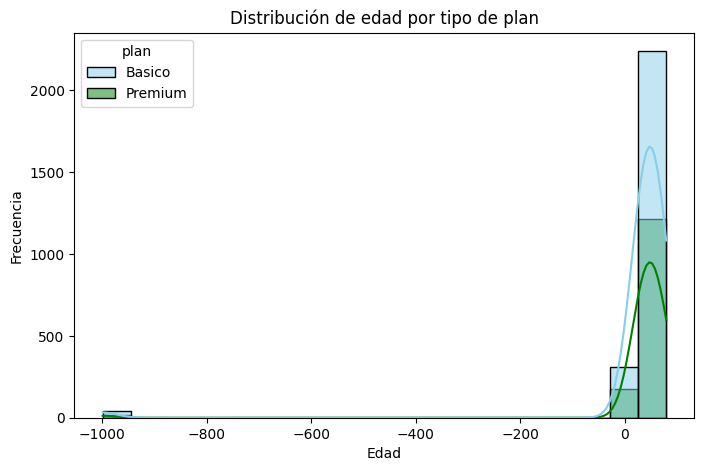

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(
    data=dataset_final,
    x="age",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"],
    kde=True
)
plt.title("Distribución de edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()


Insight

La distribución de edades es similar entre los planes Básico y Premium.

El plan Premium muestra una ligera mayor concentración en edades medias.

No se observan diferencias fuertes de edad entre planes.

Tipo de distribución

Aproximadamente simétrica, con ligera concentración en edades centrales.

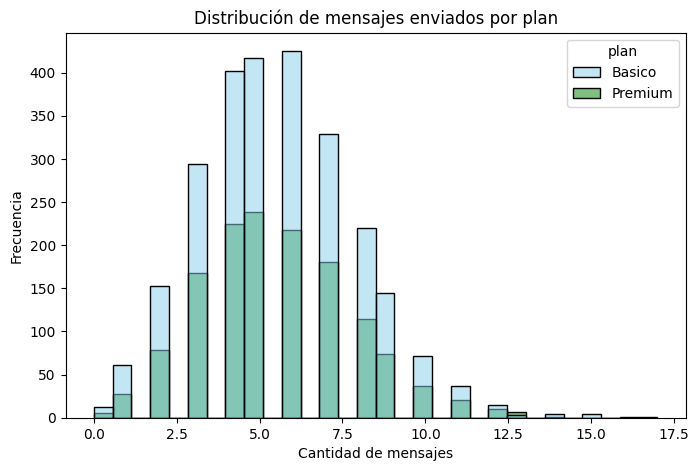

In [31]:

plt.figure(figsize=(8,5))
sns.histplot(
    data=dataset_final,
    x="cant_mensajes",
    hue="plan",
    bins=30,
    palette=["skyblue", "green"]
)
plt.title("Distribución de mensajes enviados por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()


Insight

Los usuarios Premium envían más mensajes que los usuarios Básico.

En el plan Básico predominan usuarios con bajo o nulo envío de mensajes.

Los valores altos (heavy users) se concentran principalmente en Premium.

Tipo de distribución

Sesgada a la derecha.

Muchos valores bajos y pocos valores muy altos.



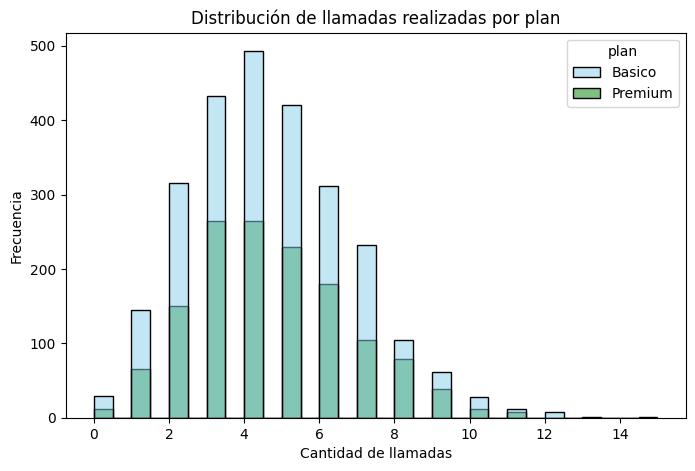

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=dataset_final,
    x="cant_llamadas",
    hue="plan",
    bins=30,
    palette=["skyblue", "green"]
)
plt.title("Distribución de llamadas realizadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


Insight

El plan Premium concentra usuarios con mayor número de llamadas.

En el plan Básico hay una alta proporción de usuarios con cero o pocas llamadas.

Se observan usuarios intensivos principalmente en Premium.

Tipo de distribución

Sesgada a la derecha.

Presencia de outliers (usuarios con muchas llamadas).


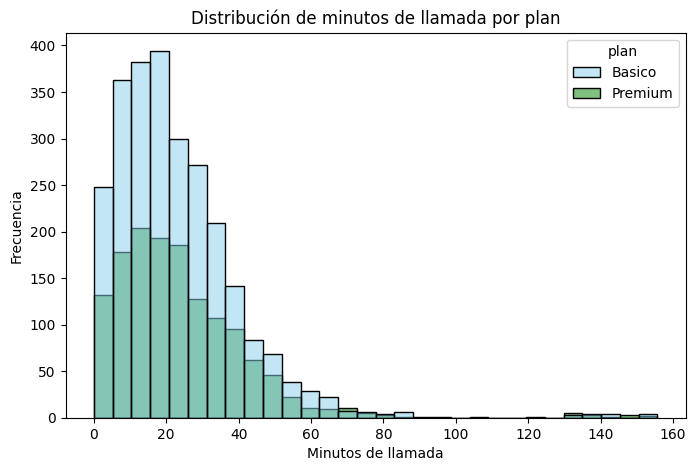

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=dataset_final,
    x="cant_minutos_llamada",
    hue="plan",
    bins=30,
    palette=["skyblue", "green"]
)
plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()



Insight

Los usuarios Premium acumulan significativamente más minutos de llamada.

En el plan Básico predominan usuarios con poco o ningún consumo en llamadas.

Los valores extremos corresponden a heavy callers Premium.

Tipo de distribución

Fuertemente sesgada a la derecha.

Cola larga con outliers claros.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

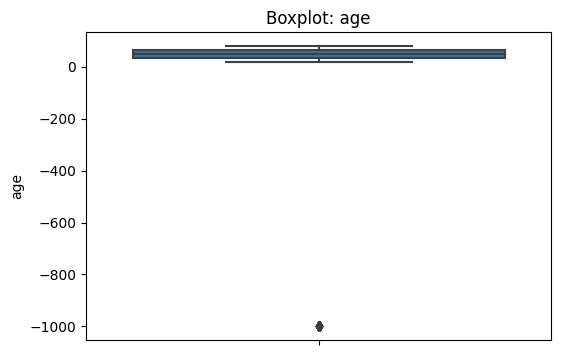

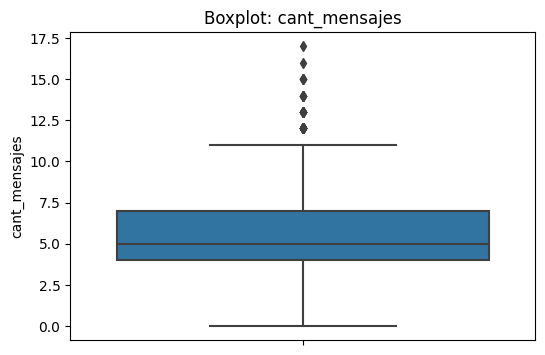

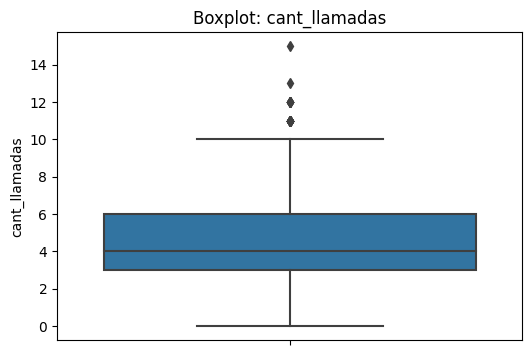

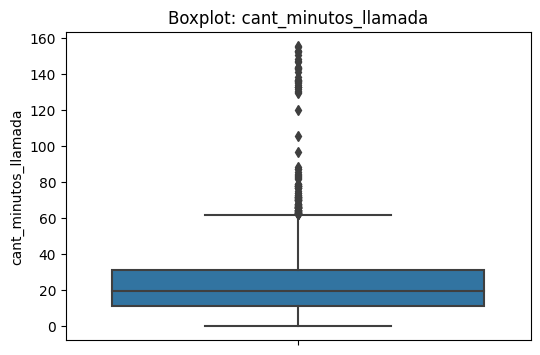

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

columnas_numericas = [
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=dataset_final,
        y=col
    )
    plt.title(f"Boxplot: {col}")
    plt.ylabel(col)
    plt.show()



Insights (después de los boxplots)

age:
No presenta outliers relevantes. La distribución es compacta y los valores extremos son coherentes con rangos de edad plausibles.

cant_mensajes:
Presenta outliers superiores claros. Corresponden a usuarios con uso intensivo de mensajes (heavy users).

cant_llamadas:
Se observan outliers en el extremo superior, asociados a usuarios con alta frecuencia de llamadas.

cant_minutos_llamada:
Presenta outliers superiores muy marcados, típicos de variables de consumo acumulado.

In [35]:
columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

limites_iqr = {}

for col in columnas_limites:
    Q1 = dataset_final[col].quantile(0.25)
    Q3 = dataset_final[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    limites_iqr[col] = limite_superior




In [36]:
dataset_final[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


Insights finales: ¿mantener o no los outliers?

cant_mensajes:
👉 Se mantienen los outliers.
Representan usuarios con comportamiento real de alto consumo y son relevantes para el análisis de uso.

cant_llamadas:
👉 Se mantienen los outliers.
Corresponden a heavy callers, un segmento natural en este tipo de datos.

cant_minutos_llamada:
👉 Se mantienen los outliers.
Aunque son valores extremos, reflejan patrones reales de uso intensivo y no errores de medición.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = "Alto uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5),
    "grupo_uso"
] = "Bajo uso"

user_profile.loc[
    (user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"] < 10) &
    (user_profile["grupo_uso"] != "Bajo uso"),
    "grupo_uso"
] = "Uso medio"



In [38]:
user_profile.head()



,user_id,id,duration,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso
0,10000,10,23.70,3.0,7.0,23.70,Uso medio
1,10001,15,33.18,10.0,5.0,33.18,Alto uso
2,10002,7,10.74,2.0,5.0,10.74,Uso medio
3,10003,14,8.99,3.0,11.0,8.99,Alto uso
4,10004,7,8.01,3.0,4.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:

print("Columnas en user_profile:")
print(user_profile.columns.tolist())


Columnas en user_profile:
['user_id', 'id', 'duration', 'cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada', 'grupo_uso', 'grupo_edad']


In [41]:
print("\nPrimeras 5 filas:")
print(user_profile.head())


Primeras 5 filas:
   user_id  id  duration  cant_llamadas  cant_mensajes  cant_minutos_llamada  \
0    10000  10     23.70            3.0            7.0                 23.70   
1    10001  15     33.18           10.0            5.0                 33.18   
2    10002   7     10.74            2.0            5.0                 10.74   
3    10003  14      8.99            3.0           11.0                  8.99   
4    10004   7      8.01            3.0            4.0                  8.01   

   grupo_uso    grupo_edad  
0  Uso medio  Adulto Mayor  
1   Alto uso  Adulto Mayor  
2  Uso medio  Adulto Mayor  
3   Alto uso  Adulto Mayor  
4   Bajo uso  Adulto Mayor  


In [42]:
# Verificar si tienes dataset_final
if 'dataset_final' in locals():
    print("Columnas en dataset_final:")
    print(dataset_final.columns.tolist())
    print("\nPrimeras filas:")
    print(dataset_final.head())

Columnas en dataset_final:
['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan', 'churn_date', 'id', 'duration', 'cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada']

Primeras filas:
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date    id  duration  cant_llamadas  cant_mensajes  \
0   Basico        NaN  10.0     23.70            3.0            7.0   
1   Basico        NaN  15.0     33.18           10.0            5.0   
2   Basico        NaN   7.0     10.74            2.0            5.0   
3  Premium        NaN

In [43]:
# Agregar la columna age desde dataset_final
user_profile = user_profile.merge(
    dataset_final[['user_id', 'age']], 
    on='user_id', 
    how='left'
)

In [44]:
# Verificar las nuevas columnas
print("Columnas después del merge:")
print(user_profile.columns.tolist())
print("\nPrimeras filas con age:")
print(user_profile[['user_id', 'age', 'grupo_edad']].head())

Columnas después del merge:
['user_id', 'id', 'duration', 'cant_llamadas', 'cant_mensajes', 'cant_minutos_llamada', 'grupo_uso', 'grupo_edad', 'age']

Primeras filas con age:
   user_id  age    grupo_edad
0    10000   38  Adulto Mayor
1    10001   53  Adulto Mayor
2    10002   57  Adulto Mayor
3    10003   69  Adulto Mayor
4    10004   63  Adulto Mayor


In [45]:
# Crear columna grupo_edad (resetear primero)
user_profile["grupo_edad"] = "Adulto Mayor"

user_profile.loc[
    user_profile["age"] < 30,
    "grupo_edad"
] = "Joven"

user_profile.loc[
    (user_profile["age"] < 60) & (user_profile["grupo_edad"] != "Joven"),
    "grupo_edad"
] = "Adulto"

In [46]:
# verificar cambios
user_profile.head()

,user_id,id,duration,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad,age
0,10000,10,23.70,3.0,7.0,23.70,Uso medio,Adulto,38
1,10001,15,33.18,10.0,5.0,33.18,Alto uso,Adulto,53
2,10002,7,10.74,2.0,5.0,10.74,Uso medio,Adulto,57
3,10003,14,8.99,3.0,11.0,8.99,Alto uso,Adulto Mayor,69
4,10004,7,8.01,3.0,4.0,8.01,Bajo uso,Adulto Mayor,63


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

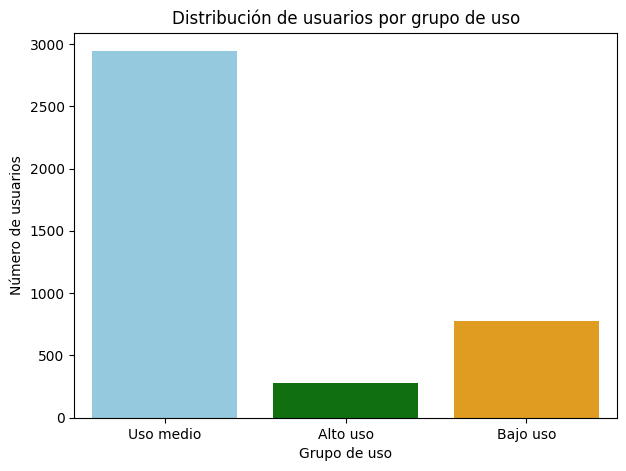

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Número de usuarios")
plt.show()


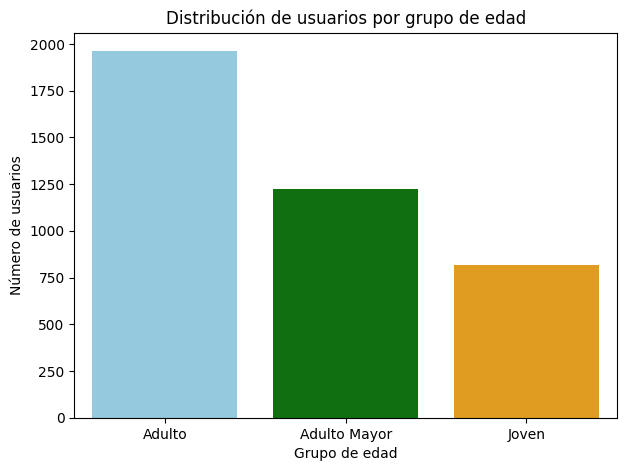

In [48]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de usuarios")
plt.show()




---
## 
🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


Insight Ejecutivo para Stakeholders – ConnectaTel
1️⃣ ¿Qué problemas tenían originalmente los datos?

Se identificaron valores nulos estructurales en las columnas duration y length:

Aproximadamente el 99.9 % de los registros tipo text presentan valores nulos en duration.

Aproximadamente el 99.9 % de los registros tipo call presentan valores nulos en length.

Estos nulos no representan errores, sino que responden a la naturaleza del tipo de interacción (los mensajes no tienen duración y las llamadas no tienen longitud de texto). Por lo tanto, se clasificaron como MAR (Missing At Random) y se conservaron sin imputación para evitar introducir sesgo artificial.

Adicionalmente, las variables de uso presentan distribuciones sesgadas con valores extremos, propios de datos de consumo.

2️⃣ ¿Qué segmentos de clientes se identificaron y cómo se comportan?
🔍 Segmentación por Edad

Se identificaron tres grupos:

Jóvenes (<30 años)

Adultos (30–59 años)

Adultos Mayores (60+ años)

La mayoría de los clientes pertenece al grupo Adulto, seguido por Jóvenes y Adultos Mayores. No se observaron diferencias marcadas de edad entre planes, lo que indica que la edad no es el principal diferenciador del tipo de plan.

📊 Segmentación por Nivel de Uso

Se identificaron tres segmentos claros:

Bajo uso: pocos mensajes y llamadas (predominan en el plan Básico).

Uso medio: consumo moderado, con potencial de crecimiento.

Alto uso: usuarios intensivos, concentrados principalmente en el plan Premium.

El nivel de uso resulta ser mucho más informativo que la edad para entender el comportamiento del cliente.

3️⃣ ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los usuarios de Alto uso, especialmente aquellos en el plan Premium, son los más valiosos porque:

Generan mayor volumen de consumo (mensajes, llamadas y minutos).

Representan una parte significativa del uso total, aunque no sean la mayoría en cantidad.

Tienen mayor probabilidad de justificar planes de mayor precio o servicios adicionales.

El segmento de Uso medio también es estratégico, ya que presenta alto potencial de migración a planes Premium mediante incentivos adecuados.

4️⃣ ¿Qué patrones de uso extremo (outliers) se encontraron y qué implican?

Se identificaron outliers superiores en:

cant_mensajes

cant_llamadas

cant_minutos_llamada

Estos valores extremos corresponden a usuarios reales con consumo intensivo, no a errores de captura. Desde el punto de vista del negocio:

Representan clientes de alto valor.

Justifican la existencia de planes Premium o incluso planes especializados.

Requieren monitoreo para prevenir churn, ya que su pérdida tendría un impacto desproporcionado.

5️⃣ ¿Qué recomendaciones se proponen para el negocio?
💡 Recomendaciones estratégicas

Upselling dirigido: ofrecer planes Premium a usuarios de Uso medio del plan Básico.

Fidelización de heavy users: beneficios exclusivos para usuarios de Alto uso (bonos, descuentos, atención prioritaria).

Planes diferenciados: considerar un plan intermedio o un plan “heavy user” enfocado en alto volumen de llamadas o mensajes.

Segmentación basada en uso: priorizar el nivel de uso sobre variables demográficas para campañas comerciales.

Monitoreo continuo de outliers como indicadores de clientes de alto valor.

✅ Conclusión Ejecutiva

El análisis revela que el comportamiento de uso es el principal diferenciador de valor para ConnectaTel. Los planes actuales pueden optimizarse mediante una segmentación basada en intensidad de consumo, enfocando esfuerzos comerciales en usuarios de uso medio y alto para maximizar ingresos y retención.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`